# Machine Learning Final Proyect - Nopales
### David Villanueva Guzmán - U6110618
### Alvaro Cámara Guerra - U6110583

### Import Required Libraries

In [1]:
import sys
print(sys.executable)
import torch
print(torch.__version__)
print(torch.cuda.is_available())

c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Scripts\python.exe
2.2.0+cu118
True


In [2]:
import torch, kornia, platform

print("Torch:", torch.__version__)
print("CUDA version in torch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Kornia:", kornia.__version__)
print("Python:", platform.python_version())


Torch: 2.2.0+cu118
CUDA version in torch: 11.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU
Kornia: 0.8.2
Python: 3.11.9


c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\torch\cuda\__init__.py:218: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [3]:
!nvidia-smi

Thu Dec 25 16:26:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.05                 Driver Version: 577.05         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P0             11W /  103W |       0MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# !pip install "numpy<2.0" --force-reinstall
# !pip install kornia
import warnings
warnings.filterwarnings("ignore")

In [5]:
# For data processing
# !pip install pandas
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Integrate google drive
# from google.colab import drive
# drive.mount('/content/drive')

### Load the Dataset
Milan Dataset --

In [7]:
# Import Multiclass and Binary annotations
file_path_MC = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_multiclass.csv"
file_path_BIN = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_binary.csv"
# file_path_MC = "/home/udem09/ifros/machine-learning/annotations_multiclass.csv"
# file_path_BIN = "/home/udem09/ifros/machine-learning/annotations_binary.csv"

# Get dataframes of annotations
df_MC = pd.read_csv(file_path_MC)
df_MC.drop(columns=["Unnamed: 2", "Unnamed: 3"], inplace=True)

print(df_MC.head(10))

  file_prefix printError_physicalDefect
0  001_516_01                       0_0
1  001_516_02                       0_1
2  001_516_03                       0_0
3  001_516_04                       0_0
4  001_516_05                       0_0
5  001_516_06                       0_0
6  001_516_07                       0_0
7  001_516_08                       0_0
8  001_516_09                       0_0
9  001_516_10                       1_0


#### Data Preprocessing

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


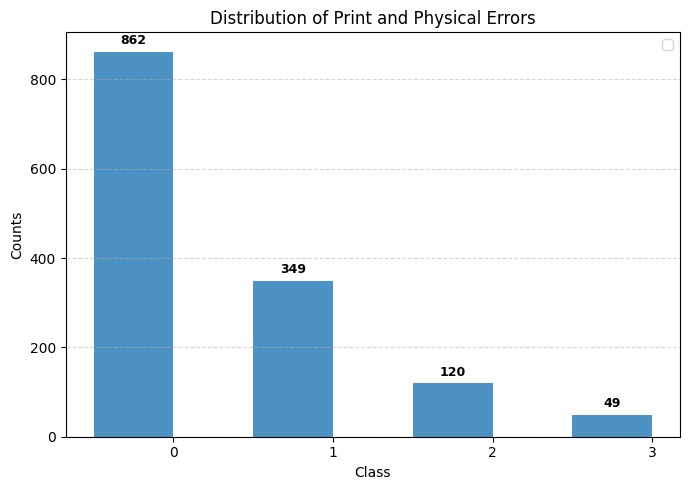

     file_prefix printError_physicalDefect  printError_physicalDefect_int
0     001_516_01                       0_0                              0
1     001_516_02                       0_1                              1
2     001_516_03                       0_0                              0
3     001_516_04                       0_0                              0
4     001_516_05                       0_0                              0
...          ...                       ...                            ...
1375  002_100_11                       0_1                              1
1376  002_100_12                       0_0                              0
1377  002_100_13                       0_0                              0
1378  002_100_14                       0_0                              0
1379  002_100_15                       1_0                              2

[1380 rows x 3 columns]


In [8]:
mapping = {
    "0_0": 0,
    "0_1": 1,
    "1_0": 2,
    "1_1": 3
}

df_MC["printError_physicalDefect_int"] = df_MC["printError_physicalDefect"].map(mapping)

# Count occurrences of each class
print_counts = df_MC["printError_physicalDefect_int"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(df_MC)

### Binary annotations

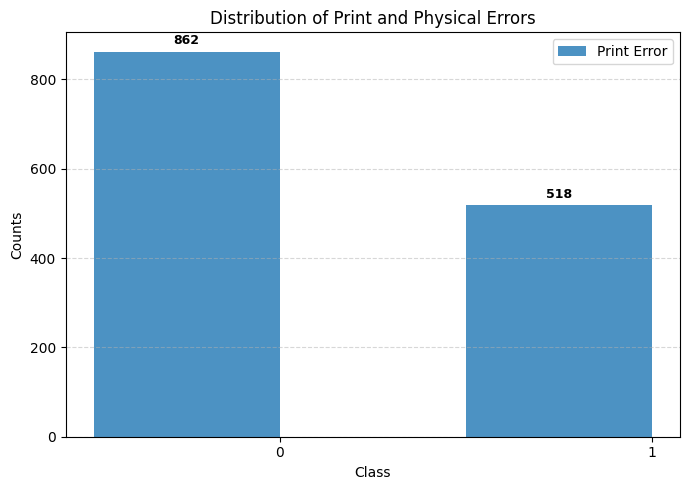

In [9]:
# Lista de strings a buscar en el nombre de la imagen

# Filtrar solo filas donde la segunda columna sea exactamente '0_0'
df_MC["binary"] = (df_MC["printError_physicalDefect_int"] != 0).astype(int)

# Count occurrences of each class
print_counts = df_MC["binary"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, label='Print Error', color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Data reduction

#### Unzip images inside google drive

In [10]:
# extract_path = "/home/udem09/ifros/machine-learning/arrays"
# extract_path = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/arrays'
extract_path = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\drive-download-20251113T114126Z-1-001\arrays"

#### Define NPYImageDataset class to load the images

In [11]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np

class NPYImageDataset(Dataset):
    def __init__(self, root_dir, names, labels, transform=None, selected_channels=None):
        """
        root_dir : Folder with .npy files
        names    : List like ['003_045_012', '002_047_12', ...]
        labels   : Array-like with class labels aligned with 'names'
        transform: torchvision transform
        selected_channels: List of channel indices to keep (e.g., [0, 3, 5])
                          If None, uses all 6 channels
        """
        self.root_dir = root_dir
        self.names = names
        self.labels = labels
        self.transform = transform
        self.selected_channels = selected_channels

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        filename = f"{name}.npy"
        path = os.path.join(self.root_dir, filename)

        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")

        img = np.load(path)                          # (H, W, C)
        img = torch.from_numpy(img).permute(2, 0, 1).float()  # (C, H, W)

        # Select specific channels if specified
        if self.selected_channels is not None:
            img = img[self.selected_channels, :, :]

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx]).long()

        return img, label
    
# GRAY, AM, G, R, W and NORMAL
# model_channels = [0, 2, 3, 4] # GRAY, G, R, W
# model_channels = [0, 2, 3, 4] # GRAY, G, R, W
model_channels = [0, 2, 3] # AM, G, R, W
# model_channels = [0, 1, 2, 3, 4, 5] # All the channels
num_channels = len(model_channels)

# channel_names = ['GRAY', 'G', 'R', 'W']  # Adjust based on your selected channels
channel_names = ['GRAY', 'G']  # Adjust based on your selected channels

In [12]:
all_names = df_MC["file_prefix"].values      # list of .npy filenames
all_labels = df_MC["binary"].values       # 0 / 1 labels

In [13]:
from sklearn.model_selection import train_test_split

# All indices as ints
indices = np.arange(len(all_names))

# Train set
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.02,
    stratify=all_labels,
    random_state=42
)

# Validation and test set
temp_labels = all_labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

In [14]:
# Apply split to names and labels
train_names = all_names[train_idx]
val_names   = all_names[val_idx]
test_names  = all_names[test_idx]

train_labels = all_labels[train_idx]
val_labels   = all_labels[val_idx]
test_labels  = all_labels[test_idx]

#### Data transforming

In [15]:
import torchvision.transforms.v2 as transforms
import torch
import kornia.augmentation as K

def scale_image(x):
    return x / 255.0

train_transform = transforms.Compose([
    # Input comes as (C,H,W) torch tensor from NPY
    # Scale to [0,1]
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    # Normalize all 6 channels
    transforms.Normalize(
        mean=[0.5]*num_channels,
        std=[0.5]*num_channels
    )
])

val_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*num_channels,
        std=[0.5]*num_channels
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

kornia_augment = torch.nn.Sequential(
    # Flips (safe for defects)
    K.RandomHorizontalFlip(p=0.5),
    K.RandomVerticalFlip(p=0.3),
    
    # Minimal geometric
    K.RandomRotation(degrees=5.0, p=0.3),
    K.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.98, 1.02), p=0.3),
    
    # Strong photometric (main augmentation)
    K.RandomBrightness((0.8, 1.2), p=0.4),
    K.RandomContrast((0.8, 1.2), p=0.4),
    # K.RandomGamma((0.85, 1.15), p=0.3),
    
    # Minimal noise and erasing
    K.RandomGaussianNoise(std=0.01, p=0.2),
    K.RandomErasing(scale=(0.01, 0.05), p=0.2),
)

In [16]:
train_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=train_names,
    labels=train_labels,
    transform=train_transform,
    selected_channels=model_channels
)

val_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=val_names,
    labels=val_labels,
    transform=val_transform,
    selected_channels=model_channels
)

test_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=test_names,
    labels=test_labels,
    transform=val_transform,
    selected_channels=model_channels
)

In [17]:
batch_size = 16

In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # Changed from 4 to 0 for debugging
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # Changed from 4 to 0 for debugging
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # Changed from commented out to 0 for debugging
    pin_memory=True
)

#### Visuazlie a sample

label = tensor(0)
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 3, 310, 310])
Label: tensor(0)


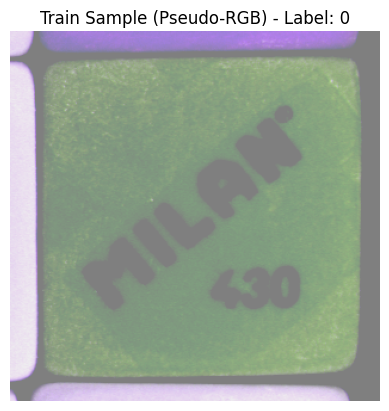

In [19]:
# Visualize ONE sample directly from the DATASET (no batching issues)

import matplotlib.pyplot as plt

# Get one raw sample from the dataset
img, label = train_dataset[150]
print("label =", label)

# Augmentation adds batch dimension, so we need to handle both cases
if img.dim() == 3:  # (C, H, W) - no batch dimension
    img_batch = img.unsqueeze(0)  # Add batch dimension for consistency
else:  # (B, C, H, W) - already has batch dimension
    img_batch = img

# Optional: apply augmentation
img_batch = kornia_augment(img_batch)

print("Type:", type(img_batch))
print("Shape:", img_batch.shape)
print("Label:", label)

# Remove batch dimension and undo normalization
img_vis = img_batch[0] * 0.5 + 0.5
img_vis = img_vis.clamp(0, 1)

# Visualize based on number of channels
if img_vis.shape[0] >= 3:
    # Show first 3 channels as pseudo-RGB
    plt.imshow(img_vis[:3].permute(1, 2, 0).cpu())
    plt.title(f"Train Sample (Pseudo-RGB) - Label: {label}")
    plt.axis("off")
    plt.show()
else:
    # Visualize each channel separately
    fig, axes = plt.subplots(1, img_vis.shape[0], figsize=(10, 5))
    
    if img_vis.shape[0] == 1:
        axes = [axes]  # Make it iterable for single channel

    for i, ax in enumerate(axes):
        ax.imshow(img_vis[i].cpu(), cmap='gray')
        ax.set_title(f"{channel_names[i]} Channel")
        ax.axis("off")

    plt.suptitle(f"Train Sample - Label: {label}")
    plt.tight_layout()
    plt.show()

### Setting the Device

### Define structure

In [20]:
# Import pretrained model ResNet50
import torchvision.models as models
import numpy as np
import torch.nn as nn

def build_model_resnet18(
    head,
    dropout_rate=0.35,
    frozen_layers = (""), # No initial frozen layer by default
    pretrained: bool =True,
    n_channels: int = 6,
    selected_channels: list[int] = None
  ):
    """
    Creates a fresh ResNet34 with:
    - ImageNet pretrained weights
    - 6-channel input
    - Custom MLP head
    - Selective layer freezing

    Safe to call once per CV fold.
    """

    def get_channel_name(idx):
        """Helper to get channel name from index"""
        names = ['GRAY', 'AM', 'G', 'R', 'W', 'NORMAL']
        return names[idx] if 0 <= idx < len(names) else f'CH{idx}'
    
    # Load the model RESNET18
    model = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    )

    # Adapts the first layer
    old_conv = model.conv1
    new_conv = nn.Conv2d(
        in_channels=n_channels,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias
    )

    # Only redefine the first layer if the number of input channels is different than 3 (original input size)
    with torch.no_grad():
        if n_channels == 3 and selected_channels is None:
            # Direct RGB copy (standard case)
            new_conv.weight = old_conv.weight
            
        elif selected_channels is not None and pretrained:
            # Smart mapping: map pretrained RGB weights to corresponding channels
            
            # Define channel-to-RGB mapping
            channel_mapping = {
                0: 0,  # GRAY → R channel (grayscale approximates red)
                1: 0,  # AM → R channel
                2: 1,  # G → G channel (GREEN MATCH)
                3: 0,  # R → R channel (RED MATCH)
                4: 0,  # W → R channel (white/grayscale)
                5: 1,  # NORMAL → G channel
            }
            
            # Initialize with random small weights (fallback)
            nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
            
            # Map pretrained weights to corresponding channels
            for new_idx, orig_channel_idx in enumerate(selected_channels):
                if orig_channel_idx in channel_mapping:
                    # Get which RGB channel to use
                    rgb_idx = channel_mapping[orig_channel_idx]
                    
                    # Copy pretrained weights from that RGB channel
                    new_conv.weight[:, new_idx:new_idx+1, :, :] = old_conv.weight[:, rgb_idx:rgb_idx+1, :, :]
                    
                    print(f"  Channel {new_idx}: {get_channel_name(orig_channel_idx)} ← RGB[{rgb_idx}] ({'R' if rgb_idx==0 else 'G' if rgb_idx==1 else 'B'})")
                else:
                    print(f"  Channel {new_idx}: {get_channel_name(orig_channel_idx)} ← Random init")
        
        else:
            # Fallback: use RGB mean for all channels
            rgb_mean = old_conv.weight.mean(dim=1, keepdim=True)
            new_conv.weight[:, :] = rgb_mean.repeat(1, n_channels, 1, 1)
            print(f"  All {n_channels} channels initialized with RGB mean")
    
    model.conv1 = new_conv

    # Freeze selected layers
    for name, param in model.named_parameters():
        param.requires_grad = not name.startswith(frozen_layers)

    # Adapt the FC layer
    model.fc = head

    # Return the virgin model 
    return model
# For resrnet34
layer_groups = {
    "conv1": ["conv1", "bn1"],
    "layer1": ["layer1"],
    "layer2": ["layer2"],
    "layer3": ["layer3"],
    "layer4": ["layer4"],
    "head":   ["fc"],   # classifier
}


### Building the model 

### Train the model

### Train and Validation Fucntions

In [21]:
import torch, kornia, platform
# Define device foor runtime
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Torch:", torch.__version__)
print("CUDA version in torch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Kornia:", kornia.__version__)
print("Python:", platform.python_version())
print(device)


Torch: 2.2.0+cu118
CUDA version in torch: 11.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU
Kornia: 0.8.2
Python: 3.11.9
cuda


In [22]:
#train function
from sklearn.metrics import average_precision_score, f1_score
import torch.nn.functional as F
import numpy as np

def Train(model, train_loader, optimizer, criterion):
    model.train()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    for i, (images, labels) in enumerate(train_loader):


        # Move augmented batch to GPU for training
        images = images.to(device)
        labels = labels.to(device)

        # Data augmentation with kornia in the GPU 
        images = kornia_augment(images)

        # Initialize backpropagation and optimization
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Backpropagation
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Convert logits → probability of positive class
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # Compute AUC-PR for the full epoch
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # AUC-PR
    if len(np.unique(all_labels)) > 1:
        auc_pr = average_precision_score(all_labels, all_probs)
    else:
        auc_pr = 0.0

    # Average loss
    avg_loss = running_loss / len(train_loader)

    # Binary predictions for F1
    preds = (all_probs >= 0.5).astype(int)

    # F1-score
    f1 = f1_score(all_labels, preds)

    return avg_loss, auc_pr, f1

#validation function
def Validate(model, val_loader, criterion):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Convert logits → probability of positive class
            probs = F.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    auc_pr = average_precision_score(all_labels, all_probs)
    avg_loss = running_loss / len(val_loader)

    # # Binary predictions for F1
    # preds = (all_probs >= 0.5).astype(int)

    # # F1-score
    # f1 = f1_score(all_labels, preds)

    # ----- FIND BEST THRESHOLD FOR F1 -----
    thresholds = np.linspace(0.0, 1.0, 200)
    f1_scores = [
        f1_score(all_labels, (all_probs >= t).astype(int)) 
        for t in thresholds
    ]
    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    return avg_loss, auc_pr, best_f1, best_threshold

In [23]:
import os
import numpy as np

bad_files = []
good = 0

for f in os.listdir(extract_path):
    if not f.lower().endswith(".npy"):
        continue

    full = os.path.join(extract_path, f)

    try:
        arr = np.load(full)
        _ = arr.shape  # force read
        good += 1
    except Exception as e:
        print("❌ Bad file:", full)
        print("   Error:", repr(e))
        bad_files.append(full)

print("\n✅ Good files:", good)
print("❌ Bad files:", len(bad_files))



✅ Good files: 1380
❌ Bad files: 0


In [24]:
# ============================================
# FOCAL LOSS - Para datasets desbalanceados
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss para clasificación binaria/multiclase con desbalance.

    Parámetros:
    -----------
    alpha : tensor o None
        Peso para cada clase. Ej: [0.3, 0.7] da más peso a clase 1
    gamma : float
        Factor de enfoque. Típicamente 2.0
        - gamma=0 equivale a CrossEntropyLoss
        - gamma>0 reduce la pérdida para ejemplos bien clasificados
    label_smoothing : float
        Suavizado de etiquetas (0.0 a 0.2 típicamente)
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # será un tensor en GPU
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs: logits del modelo, shape (N, C) donde C=num_classes
        targets: etiquetas, shape (N,) con valores 0 o 1
        """
        # Calcular log-softmax para estabilidad numérica
        log_probs = F.log_softmax(inputs, dim=1)

        # Obtener log_prob de la clase correcta para cada muestra
        # targets.unsqueeze(1) -> (N, 1)
        # gather selecciona el log_prob correspondiente a la clase correcta
        ce_loss = F.nll_loss(log_probs, targets, reduction='none')

        # Probabilidad de la clase correcta
        probs = torch.exp(log_probs)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Focal weight: (1 - pt)^gamma
        focal_weight = (1 - pt) ** self.gamma

        # Aplicar focal weight
        focal_loss = focal_weight * ce_loss

        # Aplicar alpha (peso por clase) si está definido
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss

        # Reducción
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [25]:
# Optimizer and Criterion
def compute_class_stats_from_loader(loader):
    total_per_class = torch.zeros(2)

    for _, labels in loader:
        for c in [0, 1]:
            total_per_class[c] += (labels == c).sum()

    N0 = int(total_per_class[0].item())  # non-defective
    N1 = int(total_per_class[1].item())  # defective

    return N0, N1


# Class distribution
N0, N1 = compute_class_stats_from_loader(train_loader)
print("Non-defective:", N0)
print("Defective:", N1)

# Calculate the weights
beta = 0.999
w0 = (1 - beta) / (1 - beta**N0)
w1 = (1 - beta) / (1 - beta**N1)

weights = torch.tensor([w0, w1]).to(device)

Non-defective: 845
Defective: 507


In [26]:
print(device)

cuda


In [27]:
import torch
def apply_freezing(model, layer_groups: list[str], layers_to_modify: list[str], freeze_flag: bool):
    """
    freeze_flag: True → freeze layers, False → unfreeze layers
    layers_to_modify: list of keys from layer_groups,
    """

    target_substrings = []
    for key in layers_to_modify:
        target_substrings += layer_groups[key]

    for name, module in model.named_modules():
        if any(substr in name for substr in target_substrings):
            for param in module.parameters():
                param.requires_grad = (not freeze_flag)  # True→freeze means requires_grad=False

def build_optimizer(model, lr: float, wd: float):
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    return torch.optim.AdamW(
        trainable_params,
        lr=lr,
        weight_decay=wd
    )

In [28]:
dropout_rate = 0.35

model_head = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(512, 64),
    nn.LayerNorm(64),
    nn.ReLU(),
    nn.Dropout(dropout_rate * 0.5),
    nn.Linear(64, 2)
)
# Fresh Model 
imported_model = build_model_resnet18(head=model_head, 
                                n_channels=num_channels,            # 4
                                selected_channels=model_channels,   # [R, G, GRAY, W]
                                dropout_rate=dropout_rate).to(device)

# criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.035)

alpha = torch.tensor([0.35, 0.65]).to(device)  # suma = 1.0

# gamma controla cuánto enfocarse en ejemplos difíciles
# gamma=2.0 es el valor típico del paper original
criterion = FocalLoss(
    alpha=alpha,
    gamma=2.0,
    label_smoothing=0.0
)
# Parse model to the GPU
imported_model = imported_model.to(device)

  Channel 0: GRAY ← RGB[0] (R)
  Channel 1: G ← RGB[1] (G)
  Channel 2: R ← RGB[0] (R)


In [29]:
print(imported_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
# Hyperparameters
weight_decay = 2e-3
num_epochs = 70
current_epoch = 0

# Train schedulers for alternate freezing layers
freeze_schedule = [
    (25, True, ['layer1', 'layer2', 'layer3'], 1e-4),   # Only train head, layer4, and conv1
    (55, False, ['layer1', 'layer2', 'layer3'], 2.5e-5),  # Train all
]

# Tracking lists
train_losses = []
train_f1s = []
train_aucprs = []


for block_epochs, freeze_flag, layers_to_modify, lr in freeze_schedule:

    print(f"\n=== New Training Block: {block_epochs} epochs | freeze={freeze_flag} | layers={layers_to_modify} ===")

    # Freeze/unfreeze layers
    apply_freezing(imported_model, layer_groups, layers_to_modify, freeze_flag)

    # Rebuild optimizer to include only unfrozen parameters
    optimizer = build_optimizer(imported_model, lr, weight_decay)

    # Rebuild scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=block_epochs)

    # Train inside this block
    for _ in range(block_epochs):

        # Safety break if total num_epochs is reached
        if current_epoch >= num_epochs: break

        # ---- Training ----
        train_loss, train_aucpr, train_f1 = Train(imported_model, train_loader, optimizer, criterion)

        # Log metrics
        train_losses.append(train_loss)
        train_aucprs.append(train_aucpr)
        train_f1s.append(train_f1)

        print(
            f"Epoch [{current_epoch+1}/{num_epochs}] "
            f"| Freeze={freeze_flag} | Layers={layers_to_modify} "
            f"| Train Loss={train_loss:.4f} Train AUC={train_aucpr:.4f} "
        )

        # Step scheduler
        scheduler.step()
        current_epoch += 1
    
    # Training finished
    if current_epoch >= num_epochs: break 


=== New Training Block: 25 epochs | freeze=True | layers=['layer1', 'layer2', 'layer3'] ===
Epoch [1/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0879 Train AUC=0.3641 
Epoch [2/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0807 Train AUC=0.4040 
Epoch [3/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0808 Train AUC=0.4007 
Epoch [4/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0801 Train AUC=0.4120 
Epoch [5/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0800 Train AUC=0.4165 
Epoch [6/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0799 Train AUC=0.4140 
Epoch [7/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0790 Train AUC=0.4389 
Epoch [8/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] | Train Loss=0.0799 Train AUC=0.4141 
Epoch [9/70] | Freeze=True | Layers=['layer1', 'layer2', 'layer3'] 

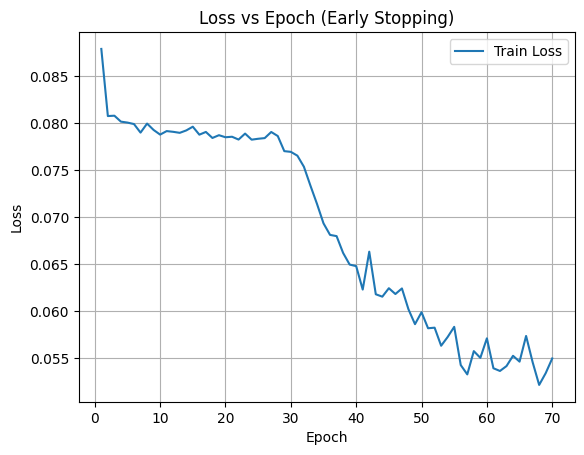

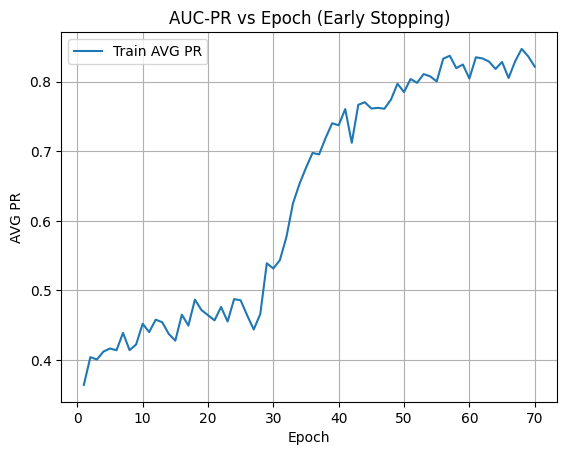

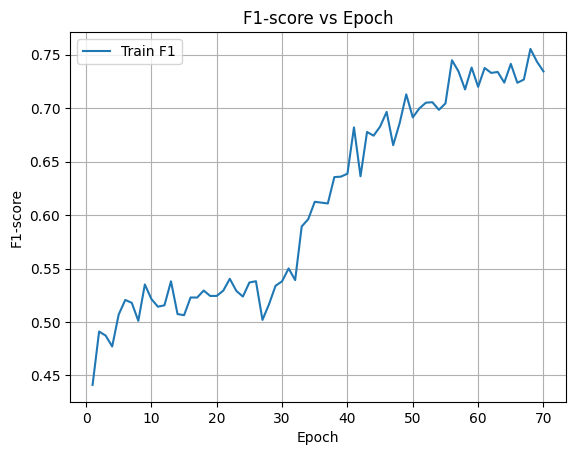

In [31]:
epochs = list(range(1, len(train_losses) + 1))

# -------- LOSS PLOT --------
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- AUC-PR PLOT --------
plt.figure()
plt.plot(epochs, train_aucprs, label='Train AVG PR')
plt.xlabel('Epoch')
plt.ylabel('AVG PR')
plt.title('AUC-PR vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- F1 SCORE PLOT --------
plt.figure()
plt.plot(epochs, train_f1s, label="Train F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("F1-score vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


AUC-PR: 0.8262


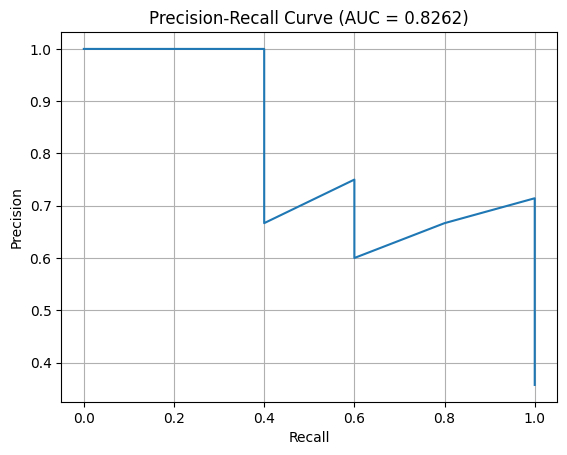

Labels distribution: [9 5]


In [32]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import torch.nn.functional as F

imported_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = imported_model(images)

        # Probabilidad de clase positiva (defecto = clase 1)
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

auc_pr = average_precision_score(all_labels, all_probs)
print(f"AUC-PR: {auc_pr:.4f}")

# Convert lists to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# Compute AUC-PR
auc_pr = average_precision_score(all_labels, all_probs)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

print("Labels distribution:", np.bincount(all_labels.astype(int)))


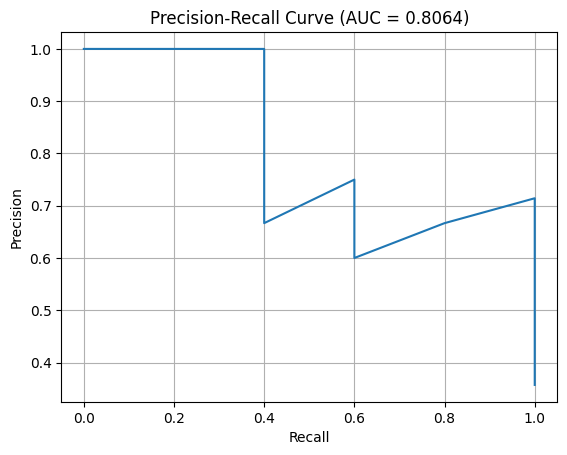

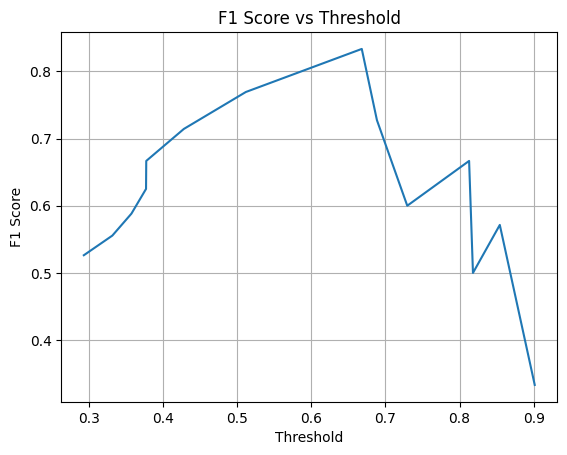

AUC-PR: 0.8064
Best F1: 0.8333
Best Threshold: 0.6681


In [33]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

imported_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = imported_model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

y_scores = torch.cat(all_probs).numpy()
y_true = torch.cat(all_labels).numpy()

# ---- PR Curve ----
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
auc_pr = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

# ---- F1 vs Threshold ----
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_idx]
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

plt.figure()
plt.plot(thresholds, f1_scores[:-1])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.grid(True)
plt.show()

print(f"AUC-PR: {auc_pr:.4f}")
print(f"Best F1: {best_f1:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")


## Saving the model

In [34]:
class EnsembleTTAModel(nn.Module):
    """
    Flexible ensemble with configurable TTA transformations
    Allows dynamic selection of which augmentations to apply
    """
    def __init__(self, models, selected_channels=None, tta_config=None):
        """
        Args:
            models: List of trained fold models
            selected_channels: List of channel indices to use
            tta_config: Dict or list specifying TTA transforms
                        If dict: {'flips': True, 'rotations': True, 'combined': False}
                        If list: ['original', 'h_flip', 'v_flip', 'rot_90', ...]
                        If None or int: Use default with that many transforms
        """
        super().__init__()
        self.models = nn.ModuleList(models)
        
        # Channel selection
        if selected_channels is not None:
            self.selected_channels = list(selected_channels)
        else:
            self.selected_channels = None
        
        # Parse TTA configuration
        self.tta_config = self._parse_tta_config(tta_config)
        self.n_tta = len(self.tta_config)
    
    def _parse_tta_config(self, tta_config):
        """
        Parse TTA configuration into list of transform names
        
        Returns: List of transform names to apply
        """
        # Default configurations
        PRESETS = {
            'none': [],
            'minimal': ['original', 'h_flip', 'v_flip'],
            'flips': ['original', 'h_flip', 'v_flip', 'hv_flip'],
            'standard': ['original', 'h_flip', 'v_flip', 'hv_flip', 'rot_90', 'rot_270'],
            'full': ['original', 'h_flip', 'v_flip', 'hv_flip', 'rot_90', 'rot_180', 'rot_270'],
            'maximum': ['original', 'h_flip', 'v_flip', 'hv_flip', 'rot_90', 'rot_180', 'rot_270', 'rot_90_h_flip'],
        }
        
        # Case 1: String preset
        if isinstance(tta_config, str):
            if tta_config in PRESETS:
                return PRESETS[tta_config]
            else:
                raise ValueError(f"Unknown preset: {tta_config}. Options: {list(PRESETS.keys())}")
        
        # Case 2: Integer (number of transforms)
        elif isinstance(tta_config, int):
            all_transforms = ['original', 'h_flip', 'v_flip', 'hv_flip', 'rot_90', 'rot_180', 'rot_270', 'rot_90_h_flip']
            return all_transforms[:tta_config]
        
        # Case 3: List of transform names
        elif isinstance(tta_config, list):
            return tta_config
        
        # Case 4: Dict configuration
        elif isinstance(tta_config, dict):
            transforms = ['original']  # Always include original
            
            if tta_config.get('h_flip', True):
                transforms.append('h_flip')
            if tta_config.get('v_flip', True):
                transforms.append('v_flip')
            if tta_config.get('hv_flip', True):
                transforms.append('hv_flip')
            if tta_config.get('rotations', False):
                transforms.extend(['rot_90', 'rot_180', 'rot_270'])
            if tta_config.get('combined', False):
                transforms.append('rot_90_h_flip')
            
            return transforms
        
        # Case 5: None (default)
        else:
            return PRESETS['standard']  # Default to standard
    
    def rotate_90(self, x):
        """90° clockwise rotation"""
        return torch.flip(x.transpose(2, 3), dims=[2])
    
    def rotate_180(self, x):
        """180° rotation"""
        return torch.flip(x, dims=[2, 3])
    
    def rotate_270(self, x):
        """270° clockwise rotation"""
        return torch.flip(x.transpose(2, 3), dims=[3])
    
    def apply_transform(self, x, transform_name):
        """
        Apply single transformation by name
        
        Args:
            x: Input tensor
            transform_name: Name of transformation to apply
        
        Returns:
            Transformed tensor
        """
        transforms = {
            'original': lambda t: t,
            'h_flip': lambda t: torch.flip(t, dims=[3]),
            'v_flip': lambda t: torch.flip(t, dims=[2]),
            'hv_flip': lambda t: torch.flip(t, dims=[2, 3]),
            'rot_90': self.rotate_90,
            'rot_180': self.rotate_180,
            'rot_270': self.rotate_270,
            'rot_90_h_flip': lambda t: torch.flip(self.rotate_90(t), dims=[3]),
            'rot_90_v_flip': lambda t: torch.flip(self.rotate_90(t), dims=[2]),
            'rot_270_h_flip': lambda t: torch.flip(self.rotate_270(t), dims=[3]),
        }
        
        if transform_name not in transforms:
            raise ValueError(f"Unknown transform: {transform_name}. Options: {list(transforms.keys())}")
        
        return transforms[transform_name](x)
    
    def tta_transforms(self, x):
        """
        Generate all configured TTA transformations
        
        Returns:
            List of transformed tensors
        """
        return [self.apply_transform(x, name) for name in self.tta_config]
    
    def forward(self, x):
        """
        Forward pass with ensemble and TTA
        
        Args:
            x: Input tensor [B, 6, H, W]
        
        Returns:
            Log probabilities [B, 2]
        """
        # Select channels
        if self.selected_channels is not None:
            x = x[:, self.selected_channels, :, :]
        
        # Generate augmented versions
        augmented_inputs = self.tta_transforms(x)
        
        # Run all models on all augmentations
        all_predictions = []
        for aug_input in augmented_inputs:
            for model in self.models:
                model.eval()
                logits = model(aug_input)
                probs = F.softmax(logits, dim=1)
                all_predictions.append(probs)
        
        # Average all predictions
        avg_probs = torch.stack(all_predictions).mean(dim=0)
        return torch.log(avg_probs + 1e-8)
    
    def get_tta_info(self):
        """Get information about current TTA configuration"""
        return {
            'n_models': len(self.models),
            'n_tta': self.n_tta,
            'total_predictions': len(self.models) * self.n_tta,
            'transforms': self.tta_config,
        }

In [35]:
print("\n" + "="*60)
print("BUILDING ENSEMBLE MODEL")
print("="*60)


# Create ensemble with TTA
ensemble_model = EnsembleTTAModel(
    models=[imported_model],
    selected_channels=model_channels,  # Your selected channels
    # tta_config='full'  # Type of augmentations in test
    tta_config='flips'  # Type of augmentations in test
).to(device)

ensemble_model.eval()


BUILDING ENSEMBLE MODEL


EnsembleTTAModel(
  (models): ModuleList(
    (0): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batc

In [36]:
print("\n" + "="*60)
print("EXPORTING TO ONNX")
print("="*60)

# Determine input size based on whether we're using channel selection
if model_channels is not None:
    # ONNX will accept 6 channels, select internally
    dummy_input_channels = 6
else:
    dummy_input_channels = num_channels

# Create dummy input
dummy_input = torch.randn(1, dummy_input_channels, 310, 310).to(device)
# Test forward pass
with torch.no_grad():
    test_output = ensemble_model(dummy_input)
    test_prob = F.softmax(test_output, dim=1)[0, 1].item()
    print(f"✅ Test forward pass successful")
    print(f"   Dummy prediction: {test_prob:.4f}")

# Export to ONNX
onnx_filename = "model_full.onnx"

torch.onnx.export(
    ensemble_model,
    dummy_input,
    onnx_filename,
    # export_params=True,
    opset_version=14,
    input_names=['input'],
    output_names=['output'],
    do_constant_folding=True,
    # dynamic_axes={
        # 'input': {0: 'batch_size'},
        # 'output': {0: 'batch_size'}
    # },
    # verbose=False
)

print(f"\n✅ ONNX model exported: {onnx_filename}")
print(f"\nModel specifications:")
print(f"   - Input:  [batch, {dummy_input_channels}, 310, 310]")
print(f"   - Output: [batch, 2] (logits)")

# Get file size
import os
file_size_mb = os.path.getsize(onnx_filename) / (1024 * 1024)
print(f"   - File size: {file_size_mb:.1f} MB")


# Verify ONNX Model

print("\n" + "="*60)
print("VERIFYING ONNX MODEL")
print("="*60)

try:
    import onnxruntime as ort
    
    # Load ONNX model
    ort_session = ort.InferenceSession(onnx_filename)
    
    # Test with same dummy input
    ort_inputs = {ort_session.get_inputs()[0].name: dummy_input.cpu().numpy()}
    ort_outputs = ort_session.run(None, ort_inputs)
    ort_logits = ort_outputs[0]
    
    # Compare with PyTorch output
    pytorch_logits = test_output.cpu().numpy()
    
    max_diff = np.abs(pytorch_logits - ort_logits).max()
    
    if max_diff < 1e-4:
        print(f"✅ ONNX verification PASSED")
        print(f"   Max difference: {max_diff:.2e}")
    else:
        print(f"⚠️  ONNX verification: Large difference detected")
        print(f"   Max difference: {max_diff:.2e}")
    
    # Show prediction
    ort_probs = np.exp(ort_logits) / np.sum(np.exp(ort_logits), axis=1, keepdims=True)
    print(f"   ONNX prediction: {ort_probs[0, 1]:.4f}")
    
except ImportError:
    print("⚠️  onnxruntime not installed. Install with: pip install onnxruntime")
except Exception as e:
    print(f"❌ ONNX verification failed: {e}")


EXPORTING TO ONNX
✅ Test forward pass successful
   Dummy prediction: 0.3565

✅ ONNX model exported: model_full.onnx

Model specifications:
   - Input:  [batch, 6, 310, 310]
   - Output: [batch, 2] (logits)
   - File size: 42.8 MB

VERIFYING ONNX MODEL
✅ ONNX verification PASSED
   Max difference: 0.00e+00
   ONNX prediction: 0.3565


In [37]:
# ============================================
# VERIFICAR QUE ONNX == PYTORCH
# ============================================
import onnxruntime as ort
import numpy as np
import torch
import torch.nn.functional as F

# Cargar ONNX
ort_session = ort.InferenceSession(onnx_filename, providers=["CPUExecutionProvider"])

# Comparar predicciones
print("Comparando PyTorch vs ONNX:")
ensemble_model.eval()
for i in range(5):
    test_input = torch.rand(1, 6, 310, 310) # Original size
    
    # PyTorch
    with torch.no_grad():
        pt_logits = ensemble_model(test_input.to(device))
        # pt_logits = wrapped_model(test_input.cpu())
        pt_prob = F.softmax(pt_logits, dim=1)[0, 1].item()
    
    # ONNX
    onnx_out = ort_session.run(None, {"input": test_input.numpy()})[0]
    onnx_prob = (np.exp(onnx_out) / np.exp(onnx_out).sum())[0, 1]
    
    print(f"   Test {i+1}: PyTorch={pt_prob:.4f}, ONNX={onnx_prob:.4f}, Diff={abs(pt_prob-onnx_prob):.6f}")

# Si Diff > 0.01 hay problema

Comparando PyTorch vs ONNX:
   Test 1: PyTorch=0.3998, ONNX=0.3998, Diff=0.000000
   Test 2: PyTorch=0.4039, ONNX=0.4039, Diff=0.000000
   Test 3: PyTorch=0.4076, ONNX=0.4076, Diff=0.000000
   Test 4: PyTorch=0.4135, ONNX=0.4135, Diff=0.000000
   Test 5: PyTorch=0.4064, ONNX=0.4064, Diff=0.000000


## Testing the model